正在加载数据并计算每分钟平均心率...


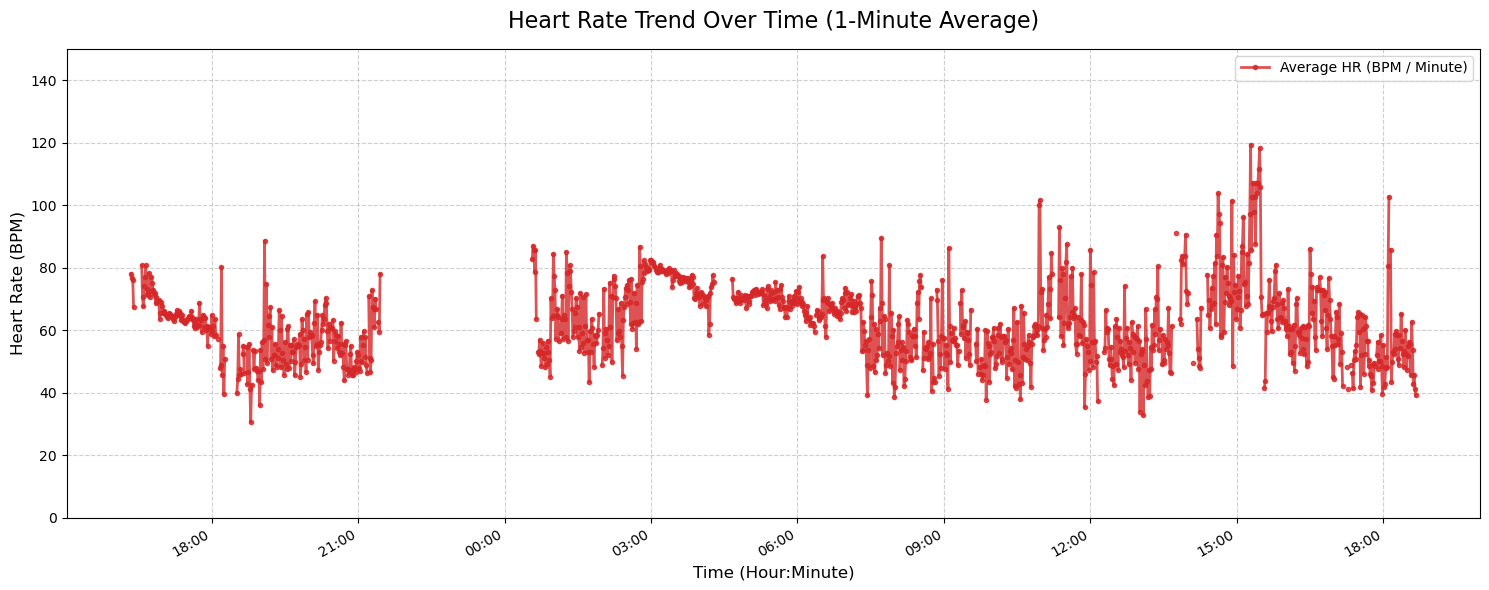

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========== 1. 数据准备 ==========
print("正在加载数据并计算每分钟平均心率...")
df = pd.read_csv("perfect_beats_features_with_motion.csv")

# 确保 peak_time 是标准时间格式
df['peak_time'] = pd.to_datetime(df['peak_time'])

# 计算每次心跳的瞬时心率 (BPM)
df['HR_BPM'] = 60.0 / df['IBI_sec']

# ========== 2. 核心魔法：按分钟重采样 (Resample) ==========
# 必须先将时间列设置为索引，才能使用时间重采样
df.set_index('peak_time', inplace=True)

# resample('1Min') 会把数据按 1 分钟切块，.mean() 计算这 1 分钟内所有心率的平均值
# 提示：如果有某分钟因为运动伪影全被剔除了，这里会自动变成 NaN，画图时会自然断开，非常科学
hr_per_minute = df['HR_BPM'].resample('1Min').mean()

# ========== 3. 开始绘制精美趋势图 ==========
plt.figure(figsize=(15, 6), facecolor='white')

# 画出每分钟心率的连线图
plt.plot(hr_per_minute.index, hr_per_minute.values, 
         color='#d62728', linewidth=2, marker='.', markersize=6, alpha=0.8,
         label='Average HR (BPM / Minute)')

# ========== 4. 坐标轴与格式美化 ==========
plt.title('Heart Rate Trend Over Time (1-Minute Average)', fontsize=16, pad=15)
plt.xlabel('Time (Hour:Minute)', fontsize=12)
plt.ylabel('Heart Rate (BPM)', fontsize=12)

# 【核心要求】格式化 X 轴时间显示为 HH:MM
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# 自动旋转 X 轴的时间标签，防止挤在一起重叠
plt.gcf().autofmt_xdate()

# 添加网格背景，方便对齐时间看心率
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.ylim([0, 150])

# # 局部自适应 Y 轴：去掉极端的异常值干扰，让主要趋势更清晰
# valid_hr = hr_per_minute.dropna()
# if len(valid_hr) > 0:
#     plt.ylim(valid_hr.quantile(0.01) - 5, valid_hr.quantile(0.99) + 5)

plt.tight_layout()
plt.savefig("hr.png")
plt.show()

正在加载数据并计算血管波形面积...


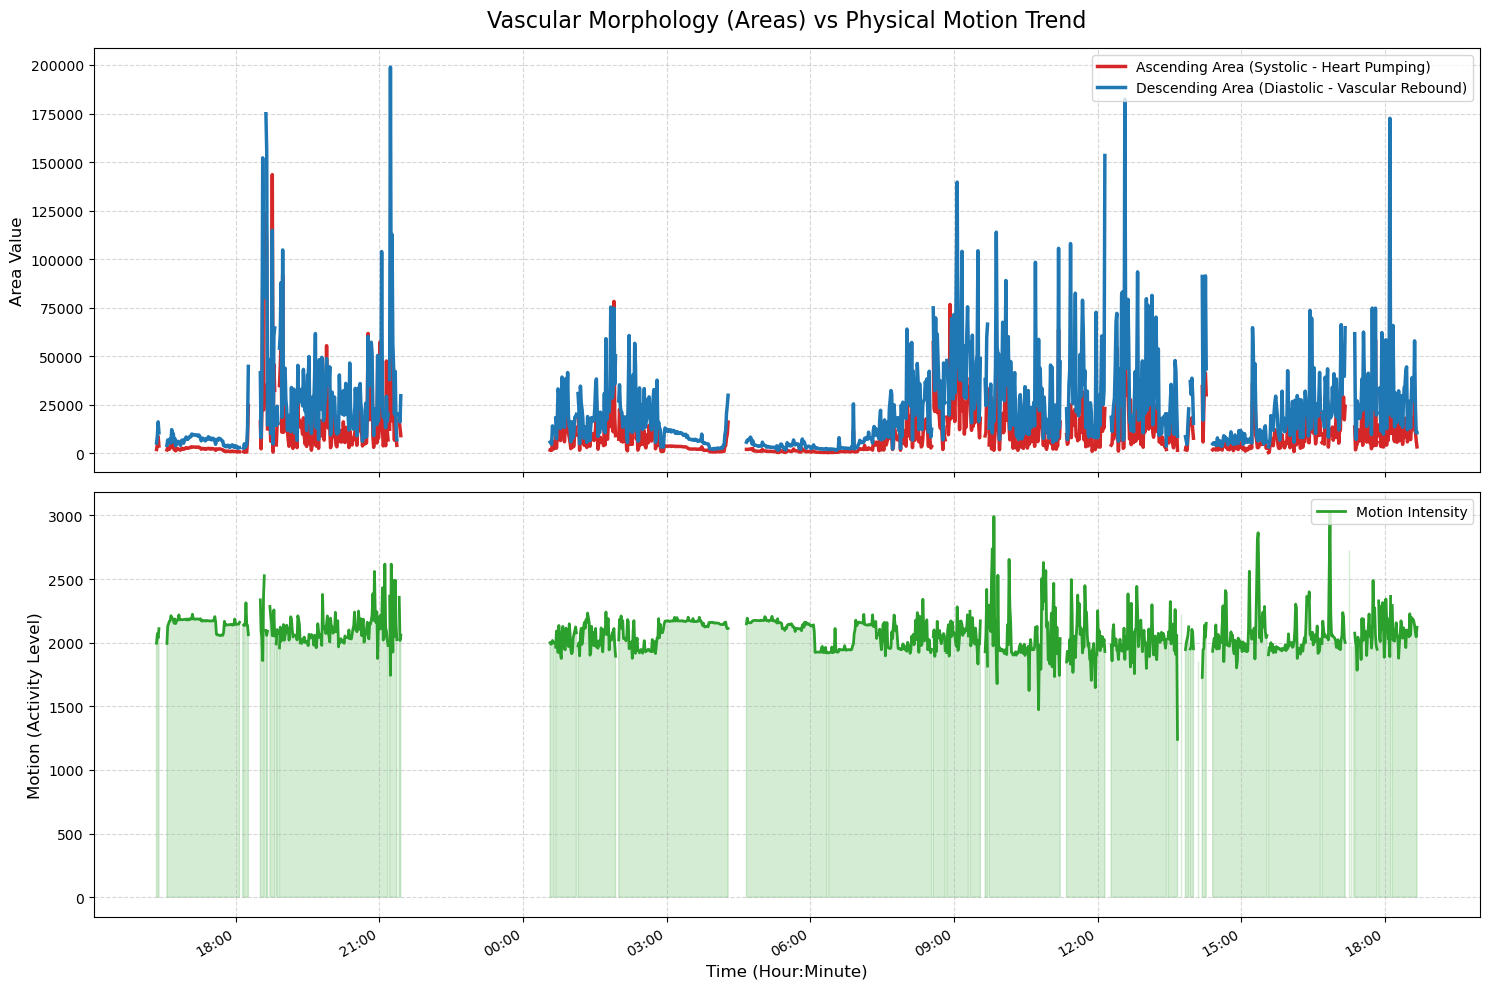

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========== 1. 加载数据与计算面积 ==========
print("正在加载数据并计算血管波形面积...")
df = pd.read_csv("perfect_beats_features_with_motion.csv")
df['peak_time'] = pd.to_datetime(df['peak_time'])

# 动态补算上升面积 (Ascending Area) 和 下降面积 (Descending Area)
# 公式: 面积 ≈ 0.5 * 底边(时间) * 高(振幅)
df['asc_area'] = 0.5 * df['rise_time_sec'] * df['amplitude']
df['desc_area'] = 0.5 * (df['IBI_sec'] - df['rise_time_sec']) * df['amplitude']

# ========== 2. 按分钟重采样 (平滑数据) ==========
df.set_index('peak_time', inplace=True)
# 提取我们需要的三列，按 1 分钟取平均值
df_minute = df[['asc_area', 'desc_area', 'motion']].resample('1Min').mean()

# ========== 3. 绘制双子图联动 =================
# 创建上下两幅图 (ax1, ax2)，sharex=True 保证它们的时间轴绝对对齐
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# -------- 上半图：血管面积趋势 --------
ax1.plot(df_minute.index, df_minute['asc_area'], color='#d62728', linewidth=2.5, 
         label='Ascending Area (Systolic - Heart Pumping)')
ax1.plot(df_minute.index, df_minute['desc_area'], color='#1f77b4', linewidth=2.5, 
         label='Descending Area (Diastolic - Vascular Rebound)')

ax1.set_title("Vascular Morphology (Areas) vs Physical Motion Trend", fontsize=16, pad=15)
ax1.set_ylabel("Area Value", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# -------- 下半图：体动强度趋势 --------
ax2.plot(df_minute.index, df_minute['motion'], color='#2ca02c', linewidth=2, 
         label='Motion Intensity')
# 用半透明绿色填充满体动曲线下方，视觉冲击力更强，一眼看出哪里在运动
ax2.fill_between(df_minute.index, 0, df_minute['motion'], color='#2ca02c', alpha=0.2)

ax2.set_xlabel("Time (Hour:Minute)", fontsize=12)
ax2.set_ylabel("Motion (Activity Level)", fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

# ========== 4. 坐标轴时间格式化 ==========
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate() # 自动旋转时间标签防止重叠

plt.tight_layout()
plt.show()

In [6]:
# import pandas as pd

# # 1. 加载数据
# df = pd.read_csv("perfect_beats_features_with_motion.csv")

# ==========================================
# 核心指标 1：计算小于 1s 的总时长
# ==========================================
# 筛选出间隔 < 1.0 秒的行，并对它们求和
valid_ibis = df.loc[df['IBI_sec'] < 1.0, 'IBI_sec']
total_continuous_sec = valid_ibis.sum()

hours = total_continuous_sec // 3600
minutes = (total_continuous_sec % 3600) // 60
seconds = total_continuous_sec % 60

print("=" * 50)
print(f"⏱️ 间隔 < 1s 的连续总时长: {total_continuous_sec:.2f} 秒")
print(f"👉 折合: {int(hours)} 小时 {int(minutes)} 分钟 {seconds:.2f} 秒")
print("=" * 50)

# ==========================================
# 核心指标 2：进阶探索 (最长的一段“无缝连续”有多长？)
# ==========================================
# 定义“断层”：只要 IBI >= 1.0 秒，或者跨越了不同的片段(segment_idx)，就算断开
condition_break = (df['IBI_sec'] >= 1.0) | (df['IBI_sec'].isna()) | (df['segment_idx'] != df['segment_idx'].shift(1))

# 利用 cumsum() 的阶梯特性，为每一段连续的区块打上唯一的 ID
df['block_id'] = condition_break.cumsum()

# 分组计算每一个连续区块的时长
block_durations = df[df['IBI_sec'] < 1.0].groupby('block_id')['IBI_sec'].sum()

if len(block_durations) > 0:
    longest_block_sec = block_durations.max()
    longest_mins = longest_block_sec // 60
    longest_secs = longest_block_sec % 60
    
    print(f"\n🏆 其中最长的一段【无缝连续(间距<1s)】波形长达: {longest_block_sec:.2f} 秒 ({int(longest_mins)} 分 {longest_secs:.2f} 秒)")
    print(f"🧩 总共由 {len(block_durations)} 个连续碎片拼接而成")
else:
    print("没有找到间隔小于 1s 的连续数据。")

⏱️ 间隔 < 1s 的连续总时长: 20875.99 秒
👉 折合: 5 小时 47 分钟 55.99 秒

🏆 其中最长的一段【无缝连续(间距<1s)】波形长达: 1245.38 秒 (20 分 45.38 秒)
🧩 总共由 3936 个连续碎片拼接而成


正在处理数据：1秒精度重采样与安全插值...


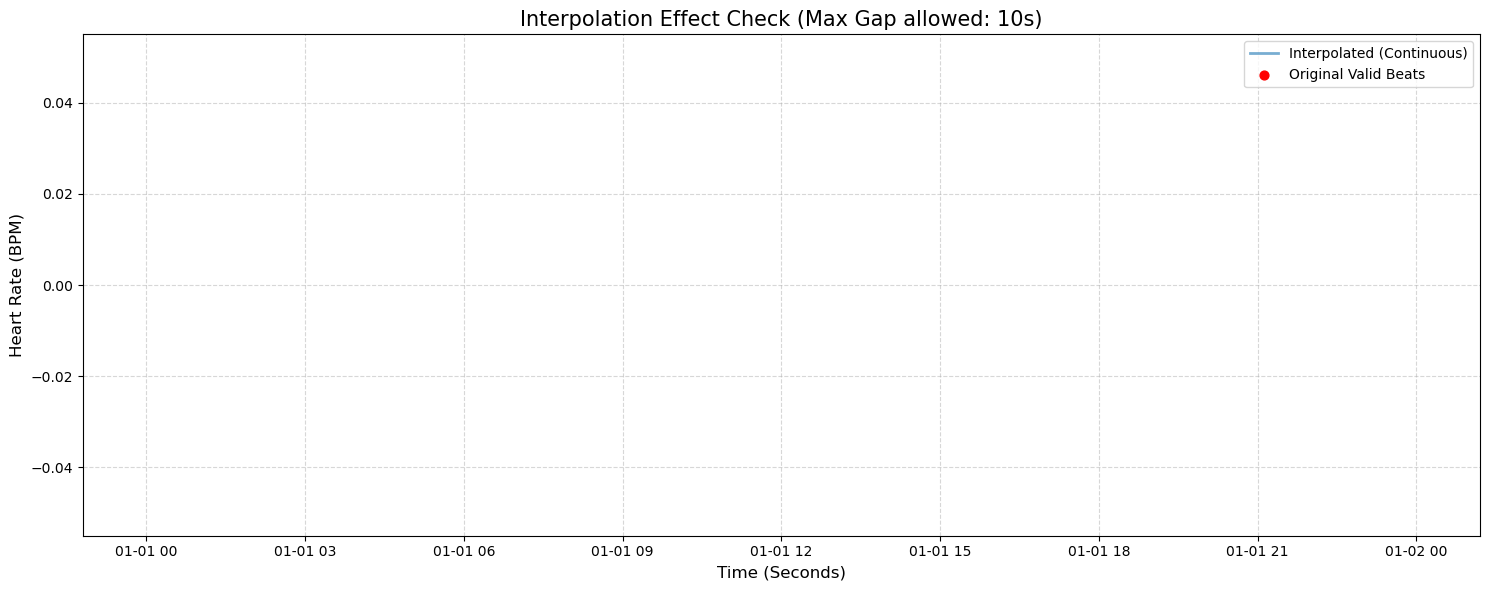

✅ 1秒精度时间序列生成完毕！已保存为 'features_1Hz_interpolated.csv'
👉 原始数据行数(心跳数): 36216
👉 1秒精度时间轴总秒数:  94734
👉 插值后成功抢救的秒数: 62538 秒 (上限设为 10 秒)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("正在处理数据：1秒精度重采样与安全插值...")

# 1. 读取并准备数据
df = pd.read_csv("perfect_beats_features_with_motion.csv")
df['peak_time'] = pd.to_datetime(df['peak_time'])

# 补齐计算你要的四个核心特征
df['HR_BPM'] = 60.0 / df['IBI_sec']
df['asc_area'] = 0.5 * df['rise_time_sec'] * df['amplitude']
df['desc_area'] = 0.5 * (df['IBI_sec'] - df['rise_time_sec']) * df['amplitude']

# 只提取需要的列，并设时间为索引
df_target = df[['peak_time', 'HR_BPM', 'asc_area', 'desc_area', 'motion']].copy()
df_target.set_index('peak_time', inplace=True)

# ==========================================
# 🌟 核心魔法：重采样与插值
# ==========================================
# 第一步：把时间轴严格对齐到每一秒（'1S'）。
# 如果同一秒内有两次心跳（比如心率>60时），取它们的平均值；如果没有心跳，就会生成 NaN。
df_1s = df_target.resample('1s').mean()

# 第二步：线性插值修补小缝隙
# limit=10 表示：最多只允许跨越 10 秒的空缺进行插值连线。如果超过10秒，保留 NaN 不连。
MAX_GAP_SECONDS = 10 
df_interpolated = df_1s.interpolate(method='time', limit=MAX_GAP_SECONDS)

# ==========================================
# 📊 可视化检查：插值到底做了什么？
# ==========================================
# 为了看清插值的细节，我们随便挑一段有数据的“局部2分钟”进行放大展示
# 自动寻找一段有数据的有效起始时间
start_zoom = df_interpolated['HR_BPM'].dropna().index[0] + pd.Timedelta(minutes=5)
end_zoom = start_zoom + pd.Timedelta(minutes=2)

zoom_raw = df_1s.loc[start_zoom:end_zoom]
zoom_interp = df_interpolated.loc[start_zoom:end_zoom]

plt.figure(figsize=(15, 6), facecolor='white')

# 画出插值后的连续线条 (较浅的连续线)
plt.plot(zoom_interp.index, zoom_interp['HR_BPM'], 
         color='#1f77b4', linewidth=2, linestyle='-', alpha=0.6, label='Interpolated (Continuous)')

# 画出最原始的实际数据点 (深色圆点)
plt.scatter(zoom_raw.index, zoom_raw['HR_BPM'], 
            color='red', s=40, zorder=5, label='Original Valid Beats')

plt.title(f"Interpolation Effect Check (Max Gap allowed: {MAX_GAP_SECONDS}s)", fontsize=15)
plt.xlabel("Time (Seconds)", fontsize=12)
plt.ylabel("Heart Rate (BPM)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. 结果保存与汇报
df_interpolated.reset_index(inplace=True)
df_interpolated.to_csv("features_1Hz_interpolated.csv", index=False)

print("=" * 50)
print(f"✅ 1秒精度时间序列生成完毕！已保存为 'features_1Hz_interpolated.csv'")
print(f"👉 原始数据行数(心跳数): {len(df_target)}")
print(f"👉 1秒精度时间轴总秒数:  {len(df_1s)}")
print(f"👉 插值后成功抢救的秒数: {df_interpolated['HR_BPM'].notna().sum()} 秒 (上限设为 {MAX_GAP_SECONDS} 秒)")
print("=" * 50)

In [9]:
df = pd.read_csv('features_1Hz_interpolated.csv')

In [10]:
df.head()

,peak_time,HR_BPM,asc_area,desc_area,motion
0,2026-05-02 16:21:46,31.250000,1584.841063,14430.394945,1986.352688
1,2026-05-02 16:21:47,78.947368,1590.709659,4772.128978,1990.035929
2,2026-05-02 16:21:48,83.349412,2239.360734,5627.556008,1995.333711
3,2026-05-02 16:21:49,84.507042,1804.429021,4938.437320,1996.115478
4,2026-05-02 16:21:50,76.923077,2178.546028,5913.196361,1990.484614


正在加载 1Hz 插值数据并生成全景仪表盘...


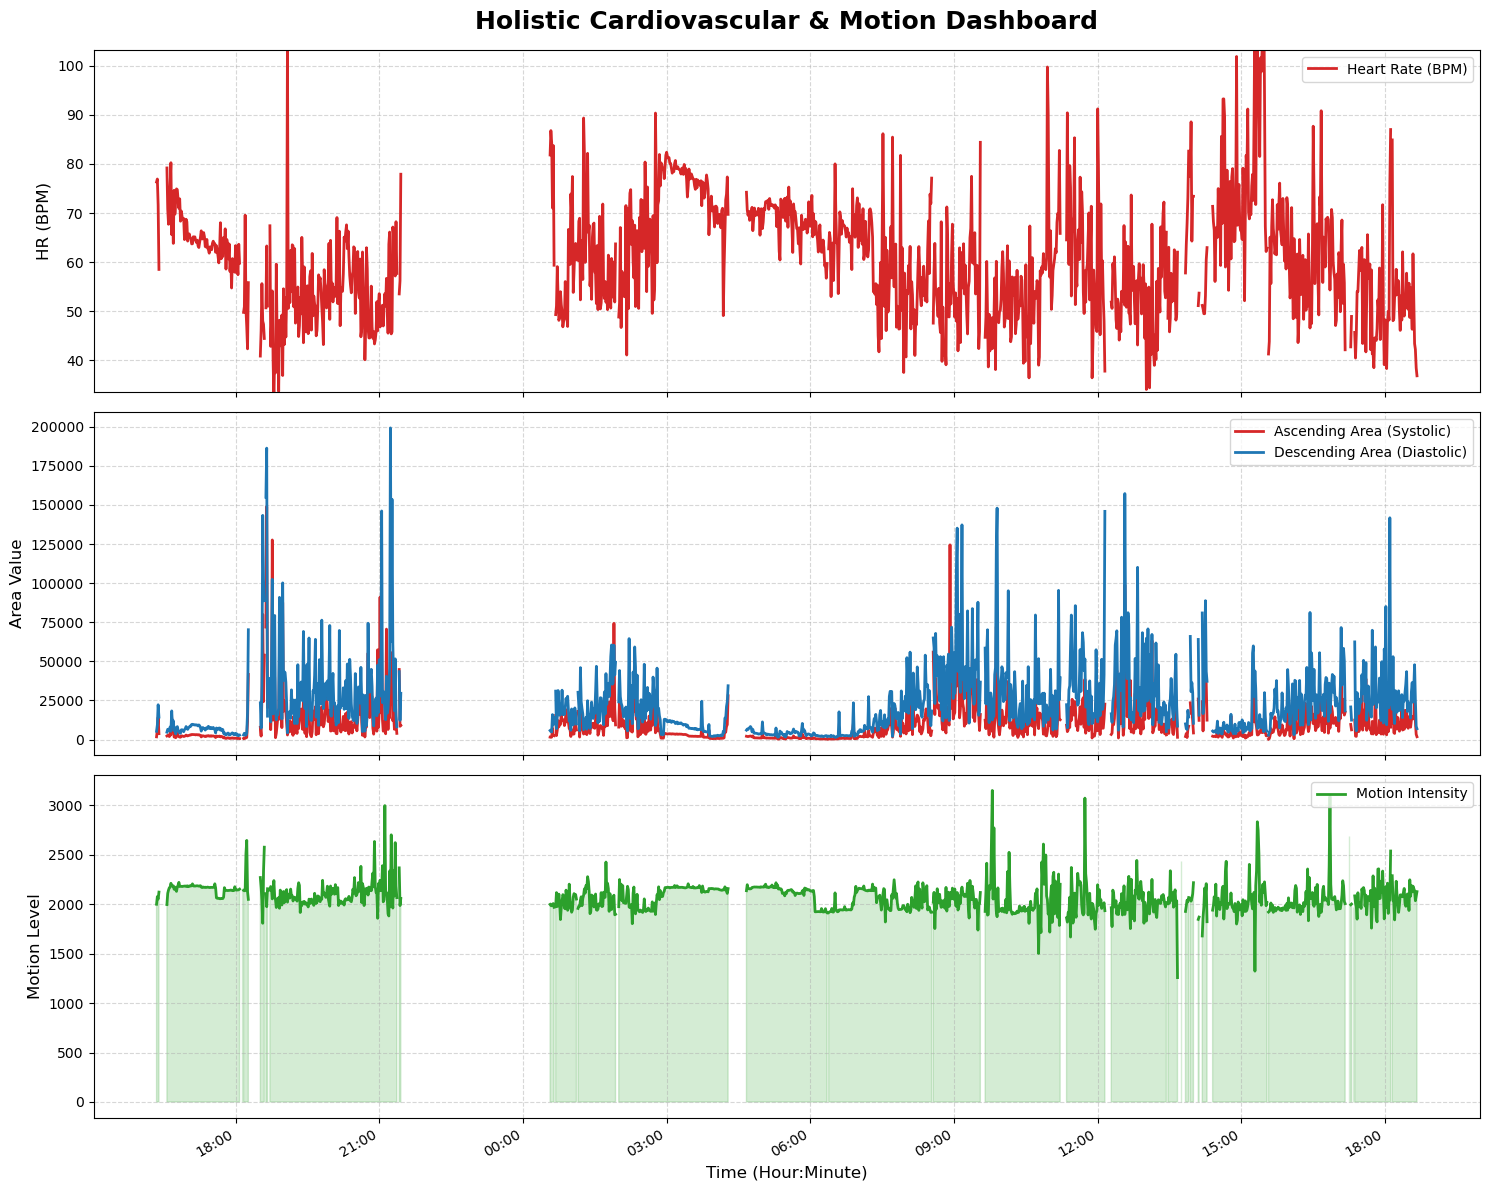

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("正在加载 1Hz 插值数据并生成全景仪表盘...")

# ========== 1. 加载与准备数据 ==========
# df = pd.read_csv('features_1Hz_interpolated.csv')
df['peak_time'] = pd.to_datetime(df['peak_time'])
df.set_index('peak_time', inplace=True)

# 为了宏观展示 20 小时的趋势，我们将 1Hz 数据按 1 分钟取平均平滑
# (你的硬盘里依然是 1Hz 的高精度数据，平滑只为了画图好看)
df_minute = df.resample('1Min').mean()

# ========== 2. 构建三子图联动 (共享 X 轴) ==========
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, facecolor='white')

# -------- 图 1：心率趋势 (Heart Rate) --------
ax1.plot(df_minute.index, df_minute['HR_BPM'], color='#d62728', linewidth=2, label='Heart Rate (BPM)')
ax1.set_title("Holistic Cardiovascular & Motion Dashboard", fontsize=18, fontweight='bold', pad=15)
ax1.set_ylabel("HR (BPM)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# 局部自适应 Y 轴 (去除极端插值异常)
if not df_minute['HR_BPM'].isna().all():
    ax1.set_ylim(df_minute['HR_BPM'].quantile(0.01) - 5, df_minute['HR_BPM'].quantile(0.99) + 10)

# -------- 图 2：血管面积形态 (Morphology Areas) --------
ax2.plot(df_minute.index, df_minute['asc_area'], color='#d62728', linewidth=2, label='Ascending Area (Systolic)')
ax2.plot(df_minute.index, df_minute['desc_area'], color='#1f77b4', linewidth=2, label='Descending Area (Diastolic)')
ax2.set_ylabel("Area Value", fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

# -------- 图 3：体动强度 (Motion) --------
ax3.plot(df_minute.index, df_minute['motion'], color='#2ca02c', linewidth=2, label='Motion Intensity')
ax3.fill_between(df_minute.index, 0, df_minute['motion'], color='#2ca02c', alpha=0.2) # 绿色阴影填充
ax3.set_xlabel("Time (Hour:Minute)", fontsize=12)
ax3.set_ylabel("Motion Level", fontsize=12)
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.5)

# ========== 3. 坐标轴时间格式化 ==========
# 强制 X 轴显示为 HH:MM
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate() # 自动旋转时间标签防止重叠

plt.tight_layout()
plt.show()